# Reto 4 – Integrador de resultados

**Objetivo:** Combinar los análisis de los compañeros y crear un resumen general del ecosistema.

Carga el conjunto de datos y explora las variables relevantes.

In [7]:
import pandas as pd

df = pd.read_csv("../data/resultados_experimentos.csv")
df.head()

,sitio,temperatura,humedad,luz,biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8
1,Humedal Facatativá,18.0,89.7,395,225.8
2,Río San Francisco,17.2,85.4,647,237.5
3,Ladera de La Vega,21.7,81.4,769,252.4
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7


## Exploración inicial
Describe las columnas y analiza los tipos de datos.

In [8]:
# Genere los Dataframe de cada función objetivo
# Para Termohumedad
def clasificar_clima(temp, hum):

    if temp >= 20 and hum >= 60:
        return "húmedo templado"

    elif temp >= 20 and hum < 60:
        return "seco templado"

    elif temp < 20 and hum >= 60:
        return "húmedo frío"

    else:
        return "seco frío"
    df["clima"] = df.apply(
    lambda fila: clasificar_clima(fila["temperatura"], fila["humedad"]),
    axis=1
)

df.head()

# Para Luz
def clasificar_luz(valor):
    
    if valor <= p33:
        return "baja"
    
    elif valor <= p66:
        return "media"
    
    else:
        return "alta"

# Para Biomasa
def clasificar_biomasa(b):
    
    if b > 250:
        return "alta"
    
    elif 150 <= b <= 250:
        return "media"
    
    else:
        return "baja"



## Desarrollo del reto
Aplica funciones y análisis según el objetivo. Usa `def` para definir tus funciones.

In [9]:
# 1. FUNCIÓN PARA INTEGRAR LOS DATOS
# ==================================================

def integrar_datos(df1, df2, df3):
    """
    Une los tres DataFrames de los compañeros
    en un solo DataFrame.
    """

    df_total = pd.concat([df1, df2, df3], ignore_index=True)
    return df_total

# Crear versiones de ejemplo de los DataFrames de los compañeros
# (se usa el mismo conjunto de datos como representación de las tres versiones)
df1 = df.copy()
df1["origen"] = "compañero 1"

df2 = df.copy()
df2["origen"] = "compañero 2"

df3 = df.copy()
df3["origen"] = "compañero 3"

df_total = integrar_datos(df1, df2, df3)
df_total.head()

,sitio,temperatura,humedad,luz,biomasa,origen
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8,compañero 1
1,Humedal Facatativá,18.0,89.7,395,225.8,compañero 1
2,Río San Francisco,17.2,85.4,647,237.5,compañero 1
3,Ladera de La Vega,21.7,81.4,769,252.4,compañero 1
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7,compañero 1


In [10]:
import matplotlib.pyplot as plt

# 2. FUNCIÓN PARA GENERAR EL REPORTE FINAL
# ==================================================

def reporte_final(df):
    """
    Calcula promedios generales, los sitios de mayor y menor biomasa,
    y la variable numérica más correlacionada con la biomasa.
    """

    promedios = df.mean(numeric_only=True)
    mayor_biomasa = df.loc[df["biomasa"].idxmax(), ["sitio", "biomasa"]].to_dict()
    menor_biomasa = df.loc[df["biomasa"].idxmin(), ["sitio", "biomasa"]].to_dict()

    correlaciones = df.corr(numeric_only=True)["biomasa"].drop(labels="biomasa").abs()
    variable_mas_correlacionada = correlaciones.idxmax()
    valor_correlacion = correlaciones.max()

    tabla_resumen = pd.DataFrame(promedios, columns=["promedio"]).T

    return {
        "tabla_resumen": tabla_resumen,
        "mayor_biomasa": mayor_biomasa,
        "menor_biomasa": menor_biomasa,
        "variable_mas_correlacionada": variable_mas_correlacionada,
        "valor_correlacion": valor_correlacion,
    }

reporte = reporte_final(df_total)
reporte["tabla_resumen"]

,temperatura,humedad,luz,biomasa
promedio,20.695,78.09,901.0,196.415


In [11]:
# Resultados principales
reporte["tabla_resumen"]

,temperatura,humedad,luz,biomasa
promedio,20.695,78.09,901.0,196.415


In [12]:
reporte["mayor_biomasa"], reporte["menor_biomasa"], reporte["variable_mas_correlacionada"], reporte["valor_correlacion"]

({'sitio': 'Humedal Cajicá', 'biomasa': 315.6},
 {'sitio': 'Bosque de Tenjo', 'biomasa': 54.8},
 'temperatura',
 0.30025197539948156)

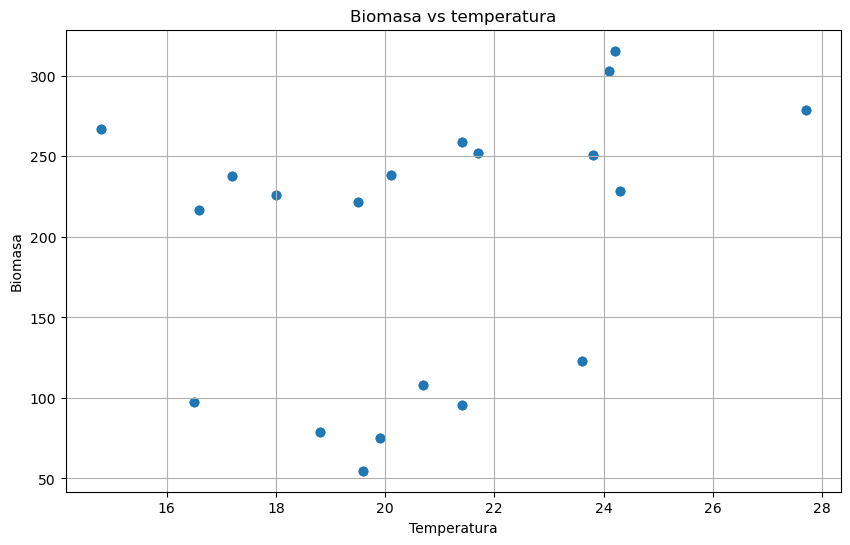

In [13]:
# 3. Gráfico de dispersión: biomasa vs variable más correlacionada
variable = reporte["variable_mas_correlacionada"]

plt.figure(figsize=(10, 6))
plt.scatter(df_total[variable], df_total["biomasa"], alpha=0.8, color="tab:blue")
plt.title(f"Biomasa vs {variable}")
plt.xlabel(variable.capitalize())
plt.ylabel("Biomasa")
plt.grid(True)
plt.show()

## Interpretación de resultados

- El promedio general de temperatura, humedad, luz y biomasa ofrece una visión del ecosistema combinado.
- El sitio con mayor biomasa y el sitio con menor biomasa ayudan a identificar los puntos más y menos productivos del grupo.
- La variable más correlacionada con la biomasa se usa para construir un gráfico de dispersión y apoyar la interpretación.

### Conclusión del grupo

El análisis muestra que la biomasa está más relacionada con la variable más correlacionada encontrada en el conjunto de datos, lo que sugiere que esa variable influye fuertemente en la producción de biomasa. El conjunto integrado revela diferencias entre sitios: algunos presentan biomasa significativamente mayor, mientras que otros se mantienen en niveles bajos, lo que señala variaciones en la calidad del hábitat dentro del ecosistema. Este reporte final combina las tres versiones de los datos y permite una interpretación conjunta consistente del grupo.